In [ ]:
# Data processing: data cleansing ---> Feature engineering ---> EDA
# Data cleansing: check and handle missing items ---> check and handle outliers ---> remove duplicates
# Feature engineering: domain knowledge feature ---> string operations
# EDA: univariate analysis ---> bivariate analysis 
# Imports
import os
import sys
import json
import re
from huggingface_hub import login
from datasets import load_dataset
from tqdm import tqdm
# Add the utils folder to Python path
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
pricer_path = os.path.join(notebook_dir, "../utils")
sys.path.insert(0, pricer_path)
# Class Item to validate the returned data and has lots of helper functions
from pricer.items import Item
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# Login to Hugging Face
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [84]:
# Download the raw collected dataset from Hugging Face
import truststore
truststore.inject_into_ssl()
username = "omarshaarawy11"
items_data = f"{username}/best_deal_01_raw_data"
dataset = load_dataset(
    items_data,
    split="train",
    token=hf_token
)
print(f"Downloaded {len(dataset):,} raw items from {items_data}")

Downloaded 61,137 raw items from omarshaarawy11/best_deal_01_raw_data


In [ ]:
# Preprocessing functions
# Handle outliers
# Bussiness keys as anything else is outlier
MIN_CHARS = 600
MIN_PRICE = 0.5
MAX_PRICE = 999.49
MAX_TEXT_EACH = 3000
MAX_TEXT_TOTAL = 4000

# We gonna remove all of these parts as it cost heavy space and not useful for our model
REMOVALS = [
    "Part Number",
    "Best Sellers Rank",
    "Batteries Included?",
    "Batteries Required?",
    "Item model number",
]

In [ ]:
# Feature engineering functions
# Domain knowledge feature
# Adjust Item weight to correct amount from pound to any
def get_weight(details):
    # Get Item Weight
    weight_str = details.get("Item Weight")
    if weight_str:
        # Split amount from unit
        parts = weight_str.split(" ")
        # Cast amount into float
        amount = float(parts[0])
        unit = parts[1].lower()
        if unit == "pounds":
            return amount
        elif unit == "ounces":
            return amount / 16
        elif unit == "grams":
            return amount / 453.592
        elif unit == "milligrams":
            return amount / 453592
        elif unit == "kilograms":
            return amount / 0.453592
        # Penny unit 
        # In this case additional part issued
        elif unit == "hundredths" and parts[2].lower() == "pounds":
            return amount / 100
    return 0

In [ ]:
# String operations
# Remove white space and trim to MAX_TEXT characters per each feature
def simplify(text_list) -> str:
    return (
        # \r is escape character
        str(text_list)
        .replace("\n", " ")
        .replace("\r", "")
        .replace("\t", "")
        .replace("  ", " ")
        .strip()[:MAX_TEXT_EACH]
    )

In [ ]:
# Remove unnecessary parts from details
# Remove white spaces from description and features
# Convert deatails into json 
# Accumelate title, description, features and details into one text
# Apply Regex
# Trim result to MAX_TEXT_TOTAL
def scrub(title, description, features, details) -> str:
    for remove in REMOVALS:
        details.pop(remove, None)
    # Accumelate all text inside result    
    result = title + "\n"
    if description:
        result += simplify(description) + "\n"
    if features:
        result += simplify(features) + "\n"
    if details:
        result += json.dumps(details) + "\n"
    pattern = r"\b(?=[A-Z0-9]{7,}\b)(?=.*[A-Z])(?=.*\d)[A-Z0-9]+\b"
    # Domain knowledge feature
    return re.sub(pattern, "", result).strip()[:MAX_TEXT_TOTAL]

In [ ]:
# Data preprocessing function: data cleansing ---> feature engineering
def parse(datapoint):
    # Handle missing values
    try:
        price = float(datapoint["price"])
    except ValueError:
        return None
    # handle outliers
    if MIN_PRICE <= price <= MAX_PRICE:
        # These fields later will return as Item object
        title = datapoint["title"]
        description = datapoint["description"]
        features = datapoint["features"]
        details = json.loads(datapoint["details"])
        # Domain knowledge feature
        weight = get_weight(details)
        # Means full description which consists of all of these parts = result
        full = scrub(title, description, features, details)
        # Handle outlier 
        if len(full) >= MIN_CHARS:
            return Item(
                title=title,
                category=datapoint["category"],
                price=price,
                full=full,
                weight=weight,
            )

In [86]:
# Apply data preprocessing function to each item in the dataset
selected_categories = [
    "All_Beauty",
    "Electronics",
    "Appliances",
    "Home_and_Kitchen",
    "Gift_Cards"
]
for category in selected_categories:
    items = [parse(datapoint) for datapoint in tqdm(dataset)]
# Handle missing items    
items = [item for item in items if item is not None]
print(f"There are {len(items):,} items from {len(dataset):,} datapoints")

100%|██████████| 61137/61137 [00:16<00:00, 3653.56it/s]


There are 21,218 items from 61,137 datapoints


In [87]:
# Incpect first item
items[0]
items[0].category

'all beauty'

In [88]:
# Inspect newly created feature full
print(items[0].full)

Lurrose 100Pcs Full Cover Fake Toenails Artificial Transparent Nail Tips Nail Art for DIY
['Description', 'The false toenails are durable with perfect length. You have the option to wear them long or clip them short, easy to trim and file them to in any length and shape you like. Plus, ABS is kind of green enviromental material, and makes the nails durable, breathable, light even no pressure on your own toenails. Fit well to your natural toenails. Non toxic, no smell, no harm to your health.', 'Feature', '- Color: As Shown.- Material: ABS.- Size: 14.3 x 7.2 x 1cm.', 'Package Including', '100 x Pieces fake toenails']
['The false toenails are durable with perfect length. You have the option to wear them long or clip them short, easy to trim and file them to in any length and shape you like.', 'ABS is kind of green enviromental material, and makes the nails durable, breathable, light even no pressure on your own nails.', 'Fit well to your natural toenails. Non toxic, no smell, no harm to 

In [89]:
# Check the most important features which is full and price
# Full feature will be our indicator as it represents the whole item
# Collect all prices and lengths of full feature per item 
prices = [item.price for item in items]
lengths = [len(item.full) for item in items]

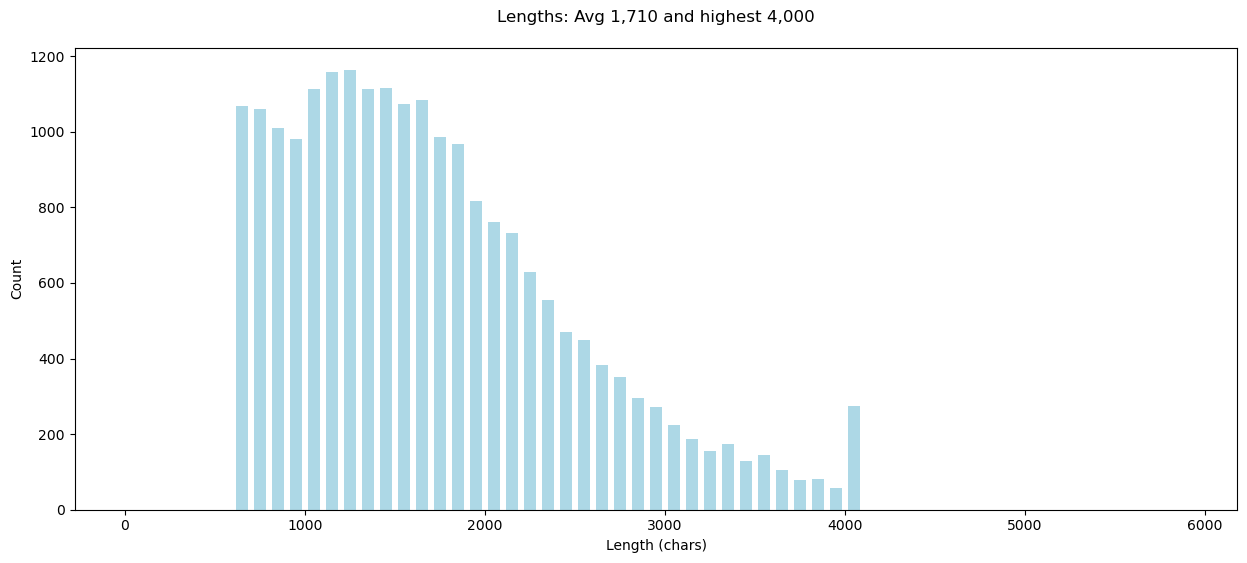

In [90]:
# EDA: extract some bussiness insights from the data
# Univeriate analysis 
# Lenghts of full feature distribution
plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

In [91]:
# Get item of max lenght of full feature
max_length = max(lengths)
max_length_item = items[lengths.index(max_length)]
print(max_length_item.full)

Manicure Kit Nail Clippers Set Professional Pedicure 15 Piece Black Stainless Steel Makeup Grooming Set Cutter Ear Pick Tweezers Scissors Nail file Gift for Man & Women (black/navy_15in1)…
['Professional Manicure pedicure kit & nail clippers set, grooming kit-15 pieces are the best product with luxurious travel case.', "The Best Manicure Set: Professional manicure tool set 15 in 1. All tools are made of high-quality stainless steel, sharp and durable, portable, comfortable to use and never rust to protect your health. black manicure set nail clippers set fingernail cutters nail scissors.Multi-Functional Nail Kit: These professional Manicure Kit Contains 16 pieces in for three functions including hand care(for fingernail part), facial care(for facial and brow trim part), and foot care (for Toenails part). The manicure pedicure set meet all you need. nail clippers set fingernail black manicure set cutters nail scissors.Easy to Use, Better Design: Our nail kit, highlight black tools with 

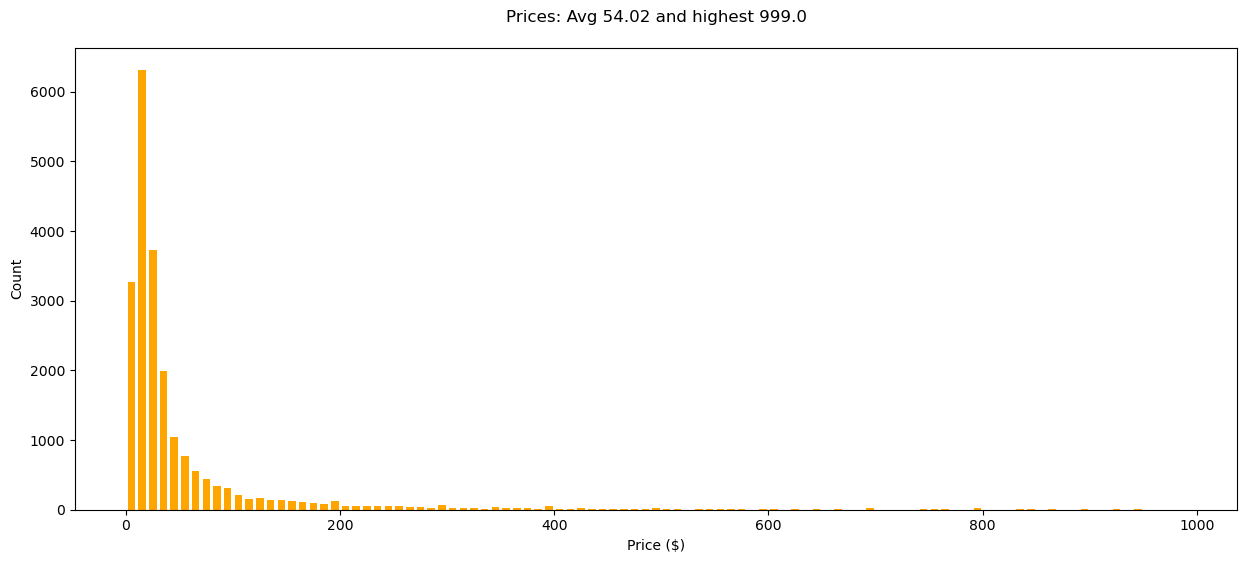

In [92]:
# prices distribution
# One concern about this dataset is prices are skewed to the cheaper items
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.2f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="orange", bins=range(0, 1000, 10))
plt.show()

In [93]:
len(items)

21218

In [94]:
# Remove duplicates
# Duplicates comes from title and full description
seen = set()
items = [item for item in tqdm(items) if not (item.title in seen or seen.add(item.title))]
seen = set()
items = [item for item in tqdm(items) if not (item.full in seen or seen.add(item.full))]

del seen
print(f"After deduplication, we have {len(items):,} items")

100%|██████████| 21143/21143 [00:00<00:00, 264260.19it/s]

After deduplication, we have 21,091 items


In [95]:
# Redoing univariate analysis step after removing duplicates
# Collect all prices and lengths of full feature per item in list to check for outliers
prices = [item.price for item in items]
lengths = [len(item.full) for item in items]

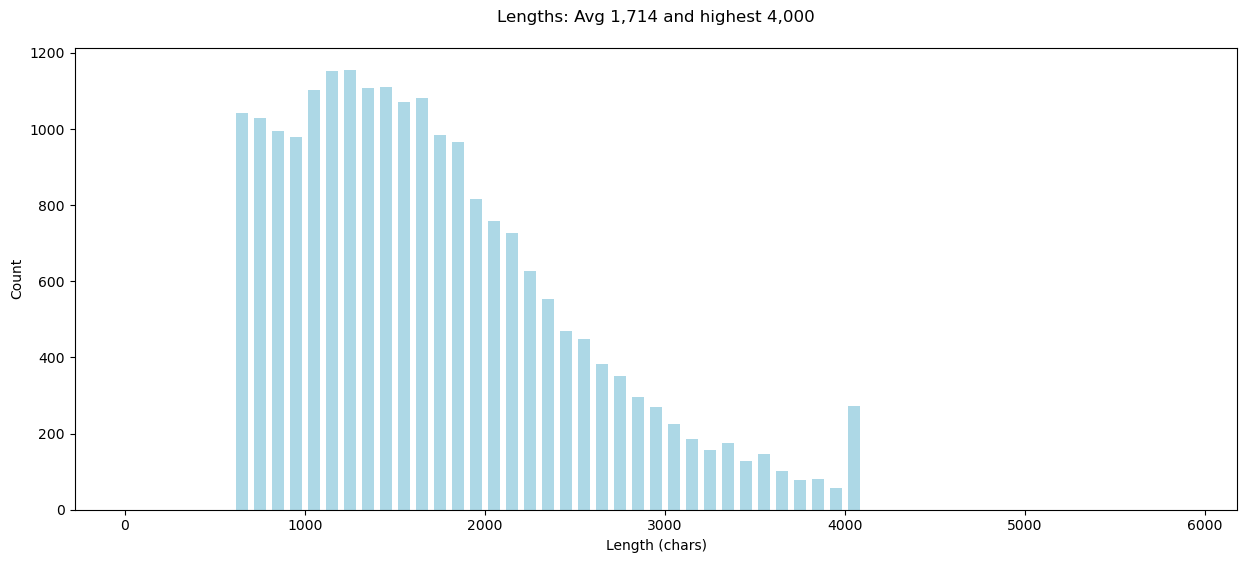

In [96]:
# Univeriate analysis 
# Lenghts of full feature distribution
plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

In [97]:
# Get item of max lenght of full feature
max_length = max(lengths)
max_length_item = items[lengths.index(max_length)]
print(max_length_item.full)

Manicure Kit Nail Clippers Set Professional Pedicure 15 Piece Black Stainless Steel Makeup Grooming Set Cutter Ear Pick Tweezers Scissors Nail file Gift for Man & Women (black/navy_15in1)…
['Professional Manicure pedicure kit & nail clippers set, grooming kit-15 pieces are the best product with luxurious travel case.', "The Best Manicure Set: Professional manicure tool set 15 in 1. All tools are made of high-quality stainless steel, sharp and durable, portable, comfortable to use and never rust to protect your health. black manicure set nail clippers set fingernail cutters nail scissors.Multi-Functional Nail Kit: These professional Manicure Kit Contains 16 pieces in for three functions including hand care(for fingernail part), facial care(for facial and brow trim part), and foot care (for Toenails part). The manicure pedicure set meet all you need. nail clippers set fingernail black manicure set cutters nail scissors.Easy to Use, Better Design: Our nail kit, highlight black tools with 

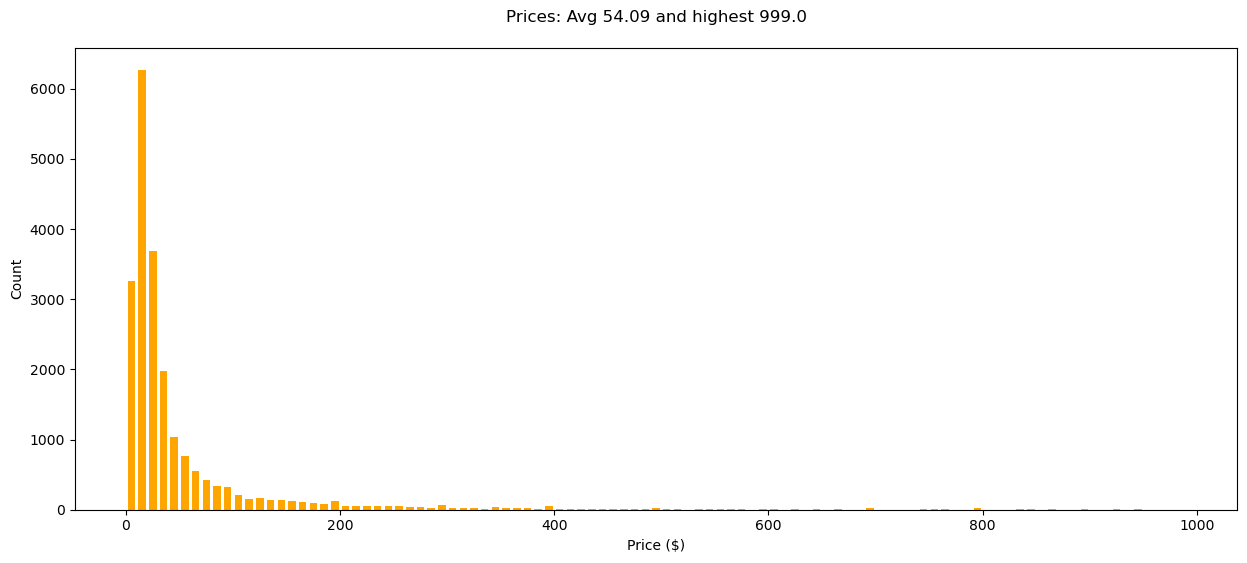

In [98]:
# Prices distribution
# One concern about this dataset is prices are skewed to the cheaper items
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.2f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="orange", bins=range(0, 1000, 10))
plt.show()

In [99]:
len(items)

21091

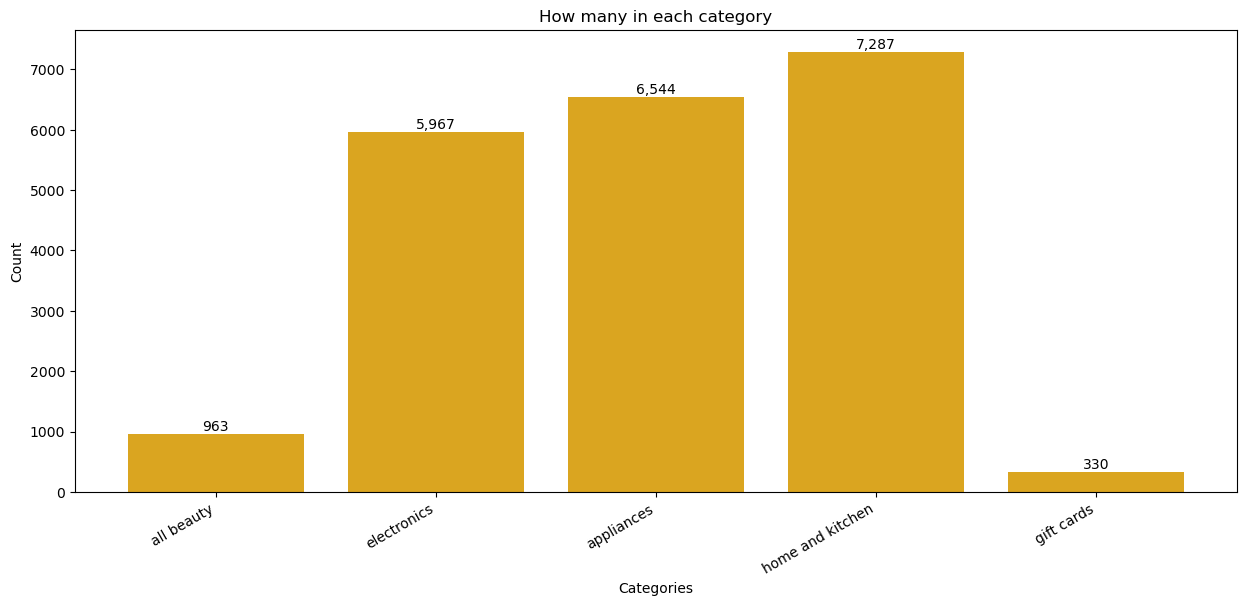

In [100]:
# Category distribution
from collections import Counter
category_counts = Counter([item.category for item in items])
categories = category_counts.keys()
counts = [category_counts[category] for category in categories]
plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')
plt.show()

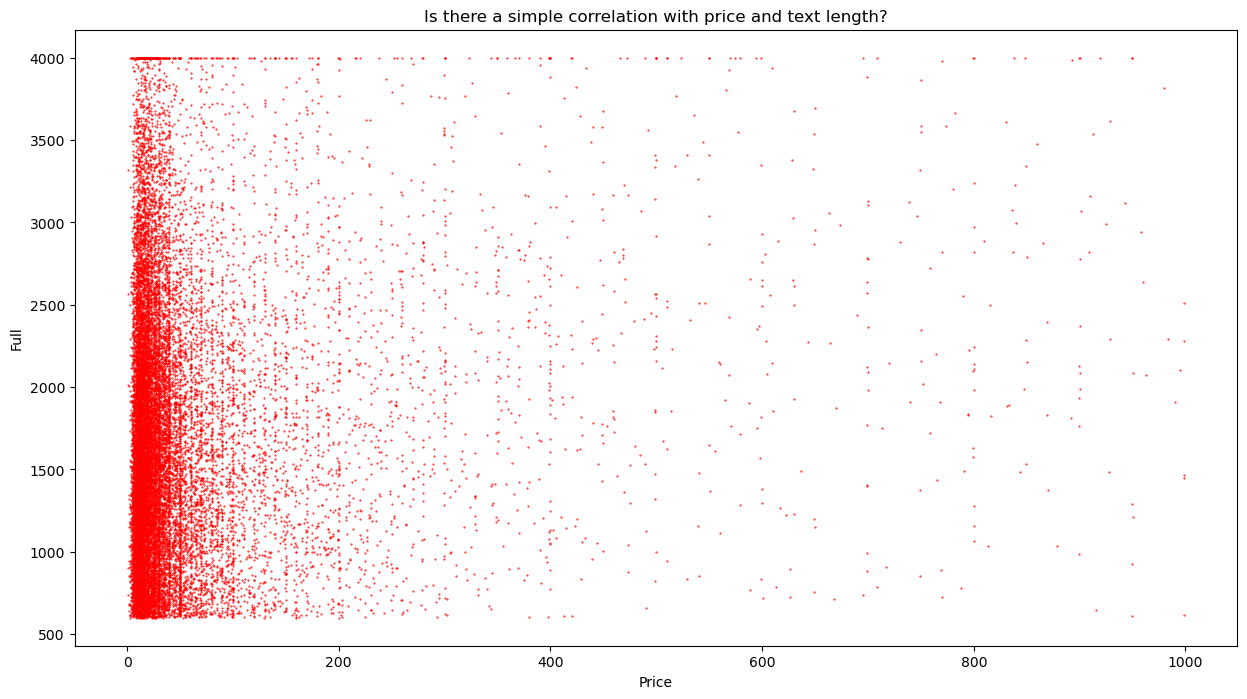

In [101]:
# Bivariate analysis between full and price
# How does the price vary with the character count?
# As we see there's no correlation
fulls = [len(item.full) for item in items]
prices = [item.price for item in items]
plt.figure(figsize=(15, 8))
plt.scatter(prices, fulls, s=0.2, color="red")
plt.xlabel('Price')
plt.ylabel('Full')
plt.title('Is there a simple correlation with price and text length?')
plt.show()

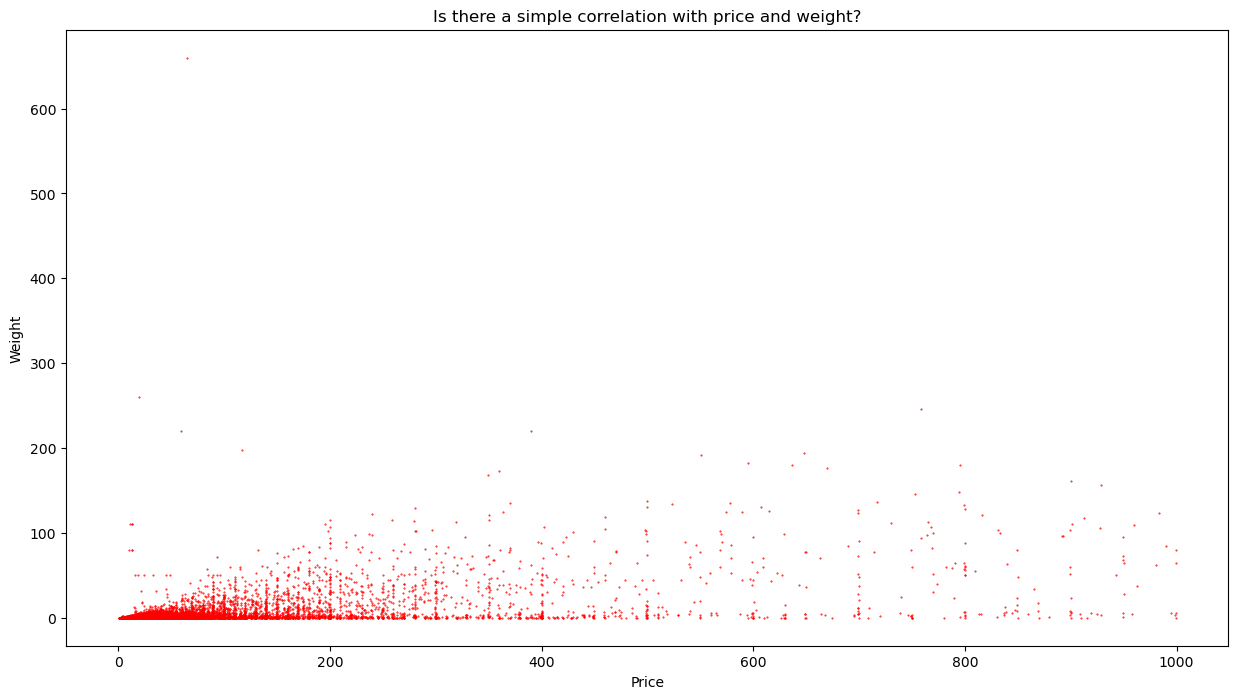

In [102]:
# Bivariate analysis between price and weight
# How does the price vary with the weight?
# As we see there's correlation
weights = [item.weight for item in items]
prices = [item.price for item in items]
plt.figure(figsize=(15, 8))
plt.scatter(prices, weights, s=0.2, color="red")
plt.xlabel('Price')
plt.ylabel('Weight')
plt.title('Is there a simple correlation with price and weight?')
plt.show()

In [ ]:
# Push dataset to Hugging Face
import truststore
truststore.inject_into_ssl()  
username = "omarshaarawy11"
items_data = f"{username}/best_deal_02_cleaned_data"
percentage = int(len(items) / 100)
train = items[:percentage * 80]
val = items[percentage * 80: percentage * 90]
test = items[percentage * 90: ]
Item.push_to_hub(items_data, train, val, test)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/17 [00:00<?, ?ba/s]

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
